In [5]:
! [ -e /content ] && pip install -Uqq fastbook
import fastbook
fastbook.setup_book()
from fastbook import *

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 3.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.1/124.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.9/246.9 kB 5.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 9.5 MB/s eta 0:00:00ta 0:00:01


Extracting the data

In [6]:
def get_data(url, presize, resize):
    path = untar_data(url)
    return DataBlock(
        blocks = (ImageBlock, CategoryBlock),  #the training data is an image block and the output is category block
        get_items = get_image_files,
        splitter = GrandparentSplitter(valid_name = 'val'),  #splitting the data based on validation dataset
        get_y = parent_label,
        item_tfms = Resize(presize),   #resizing the training images to the size of presize * presize
        batch_tfms = [*aug_transforms(min_scale=0.5, size=resize),   #applying data augmentation to images
                    Normalize.from_stats(*imagenet_stats)]
    ).dataloaders(path,bs = 128)

<div><progress max="99003388" value="99008512"></progress> 100.01% [99008512/99003388 00:02&lt;00:00]</div>

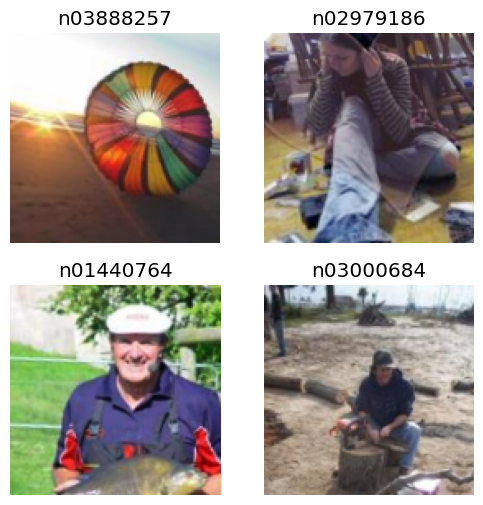

In [7]:
dls = get_data(URLs.IMAGENETTE_160, 160, 128)
dls.show_batch(max_n = 4)

CNN architecture where we use the average of activation neurons of all the channels, inorder to find the one final output


In [ ]:
def block(ni, nf):  #here ni is the number of input channels and nf is the number of features or kernels
    return ConvLayer(ni,nf,stride = 2)
def get_model():
    return nn.Sequential(
        block(3,16),
        block(16,32),
        block(32,64),
        block(64,128),
        block(128,256),
        nn.AdaptiveAvgPool2d(1),  #applying average to activation neurons of all the feature maps
        Flatten(),
        nn.Linear(256, dls.c)
    )
    